# Crop Recommendation System - Data Exploration & Model Training

This Jupyter Notebook covers data exploration, preprocessing, model training, evaluation, feature importance analysis, and model serialization using a Random Forest Classifier.

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Load dataset with pandas, show shape, head(), info(), null check, class distribution
df = pd.read_csv('data/Crop_recommendation.csv')

print("Dataset Shape:", df.shape)
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Class Distribution ---")
print(df['label'].value_counts())

Dataset Shape: (2200, 8)

--- First 5 Rows ---


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB

--- Missing Values Check ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- Class Distribution ---
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100


In [3]:
# 3. Split into features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)
print("Feature columns:", list(X.columns))

Features shape (X): (2200, 7)
Target shape (y): (2200,)
Feature columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [4]:
# 4. Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape - X_train:", X_train.shape, "y_train:", y_train.shape)
print("Testing set shape - X_test:", X_test.shape, "y_test:", y_test.shape)

Training set shape - X_train: (1760, 7) y_train: (1760,)
Testing set shape - X_test: (440, 7) y_test: (440,)


In [5]:
# 5. Train a RandomForestClassifier (n_estimators=100)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


Accuracy Score: 99.32%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00 

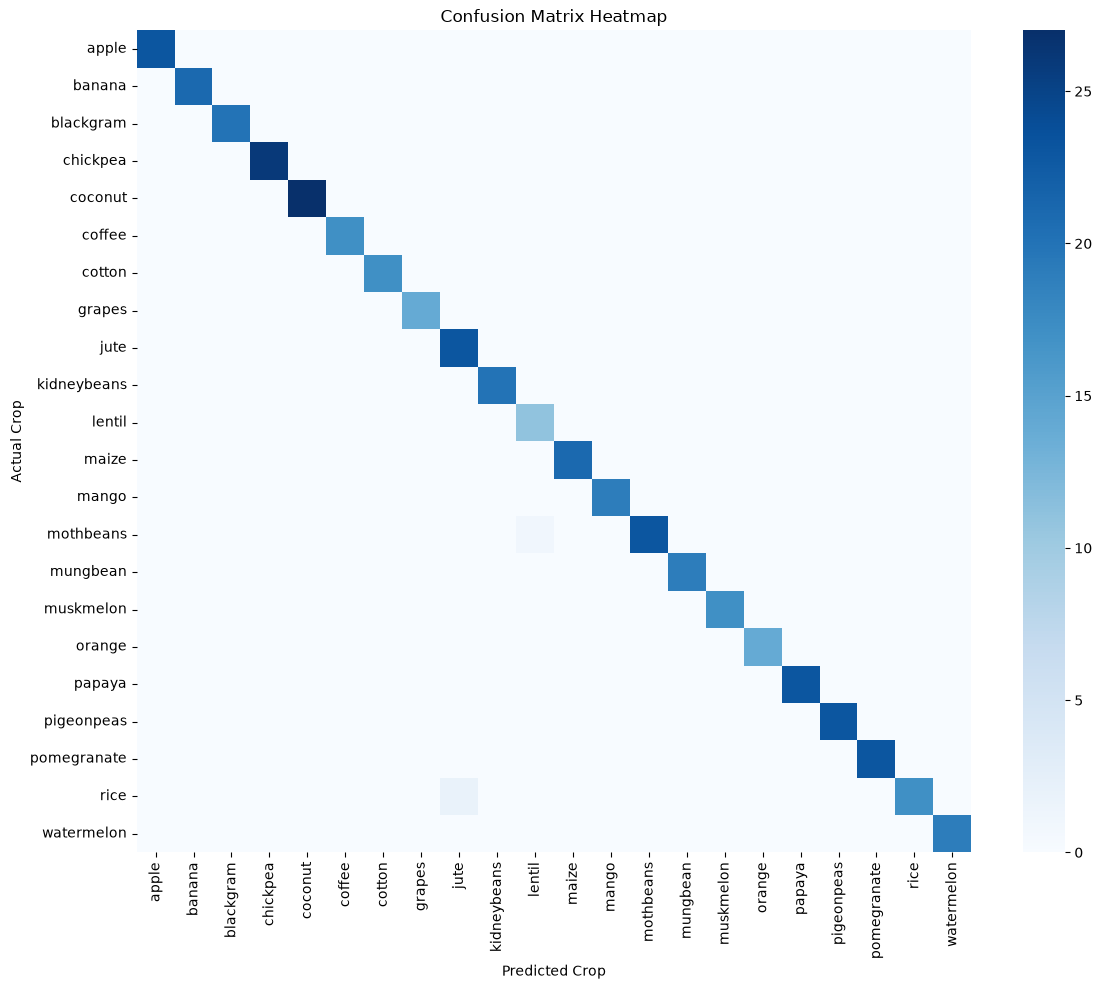

In [6]:
# 6. Evaluate with accuracy_score, classification_report, confusion matrix heatmap
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\mahaj\AppData\Local\Temp\ipykernel_18036\1070015314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=features, palette='viridis')


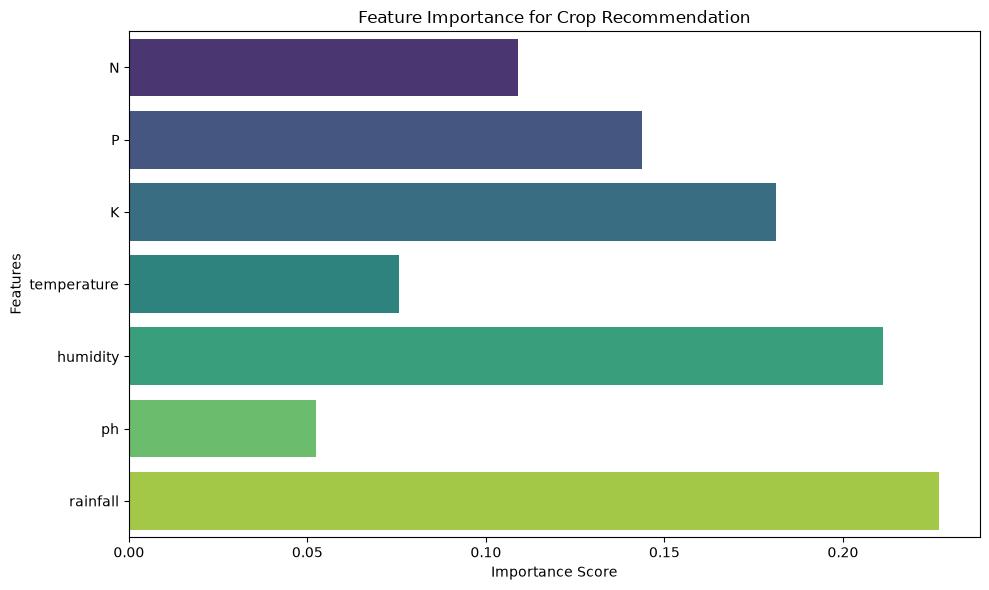

In [7]:
# 7. Plot feature importance (N, P, K, temperature, humidity, ph, rainfall)
feature_importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features, palette='viridis')
plt.title('Feature Importance for Crop Recommendation')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [8]:
# 8. Test a manual sample prediction (hardcoded values, not input())
# Sample values: [N, P, K, temperature, humidity, ph, rainfall]
sample_data = [[90, 42, 43, 20.87, 82.0, 6.5, 202.93]]

predicted_crop = model.predict(sample_data)
print(f"Sample Input Features: {sample_data[0]}")
print(f"Recommended Crop: {predicted_crop[0]}")

Sample Input Features: [90, 42, 43, 20.87, 82.0, 6.5, 202.93]
Recommended Crop: rice


C:\Users\mahaj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [9]:
# 9. Save the trained model at the end using joblib.dump(model, 'crop_model.pkl')
joblib.dump(model, 'crop_model.pkl')
print("Model successfully saved as 'crop_model.pkl'")

Model successfully saved as 'crop_model.pkl'
